# Mutual Fund Performance Analytics

## Bluestock Fintech Capstone Project

### Objectives

This notebook performs performance and risk analytics on 40 mutual fund schemes.

Metrics computed:

- Daily Returns
- CAGR (1-Year and 3-Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison
- Tracking Error

Dataset Period:
Jan 2022 – May 2026

Benchmark:
NIFTY50 and NIFTY100

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

# Load Processed Files

In [3]:
returns = pd.read_csv("../outputs/returns_computed.csv")
cagr = pd.read_csv("../outputs/cagr_report.csv")
sharpe = pd.read_csv("../outputs/sharpe_values.csv")
sortino = pd.read_csv("../outputs/sortino_values.csv")
alpha_beta = pd.read_csv("../outputs/alpha_beta.csv")
mdd = pd.read_csv("../outputs/max_drawdown.csv")
scorecard = pd.read_csv("../outputs/fund_scorecard.csv")
tracking = pd.read_csv("../outputs/tracking_error.csv")

print("Files loaded successfully")

Files loaded successfully


# Daily Returns Analysis

Daily Return Formula:

daily_return = NAV(t) / NAV(t-1) - 1

The distribution should be centered around zero and approximately bell-shaped.

In [4]:
returns["daily_return"].describe()

count    46000.000000
mean         0.000631
std          0.010286
min         -0.058102
25%         -0.005035
50%          0.000337
75%          0.006320
max          0.064713
Name: daily_return, dtype: float64

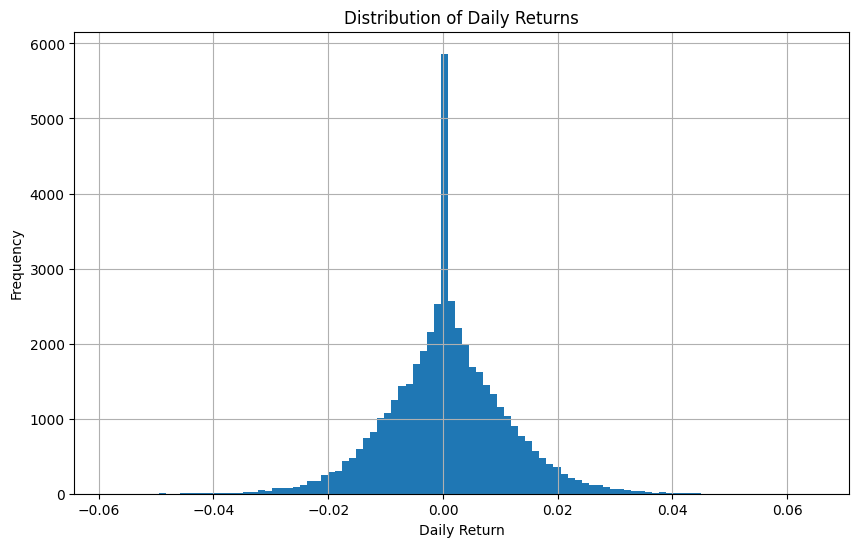

In [5]:
plt.figure(figsize=(10,6))

plt.hist(
    returns["daily_return"],
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# CAGR Analysis

CAGR measures annualized growth over a period.

Computed:
- 1 Year CAGR
- 3 Year CAGR

In [6]:
cagr.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

,amfi_code,cagr_1yr,cagr_3yr
16,119094,0.222611,0.351118
34,148567,0.203607,0.340009
24,120504,0.130643,0.324874
2,100033,0.532324,0.324425
25,120505,0.296047,0.317775
19,119551,0.604373,0.304565
30,120843,0.266571,0.295828
36,148569,0.397518,0.291789
3,101206,0.479241,0.289677
39,149324,0.651387,0.270004


# Sharpe Ratio

Sharpe = (Rp - Rf) / Std(Rp)

Risk-free rate used:
6.5%

In [7]:
sharpe.head(10)

,amfi_code,sharpe_ratio,scheme_name,fund_house
0,148567,1.447254,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
1,120843,1.305814,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,148569,1.234068,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
3,119551,1.207324,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,120505,1.179291,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
5,149323,1.131307,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
6,100033,1.092921,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
7,118632,1.080785,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
8,101206,1.026375,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
9,120504,1.025681,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF


# Sortino Ratio

Sortino uses downside volatility only.

Higher values indicate better risk-adjusted performance.

In [8]:
sortino.head(10)

,amfi_code,sortino_ratio,scheme_name,fund_house
0,148567,2.382914,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
1,120843,2.361620,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,148569,2.144491,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
3,119551,2.137677,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,120505,2.027084,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
5,149323,1.872943,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
6,118632,1.847840,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
7,100033,1.827044,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
8,120504,1.803032,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
9,101206,1.797318,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF


# Alpha and Beta

Regression benchmark:
NIFTY100

Method:
scipy.stats.linregress()

In [9]:
alpha_beta.head(10)

,amfi_code,alpha,beta,scheme_name,fund_house
0,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
1,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
2,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
3,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
4,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
5,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
6,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
7,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
8,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
9,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


# Maximum Drawdown

Maximum Drawdown measures the worst peak-to-trough decline experienced by a fund.

In [10]:
mdd.head(10)

,amfi_code,max_drawdown,trough_date,scheme_name,fund_house
0,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
1,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
2,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
3,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
4,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
5,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund
6,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
7,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF
8,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF
9,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund


# Fund Scorecard

Composite Score:

30% 3-Year CAGR Rank
25% Sharpe Rank
20% Alpha Rank
15% Expense Ratio Rank
10% Maximum Drawdown Rank

In [11]:
scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
0,Mirae Asset Large Cap Fund - Regular - Growth,86.2500
1,ICICI Pru Midcap Fund - Regular - Growth,82.2500
2,Kotak Flexicap Fund - Regular - Growth,82.0000
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500
4,ICICI Pru Bluechip Fund - Direct - Growth,80.0000
5,Axis Midcap Fund - Regular - Growth,77.0000
6,SBI Bluechip Fund - Regular Plan - Growth,74.8125
7,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875
8,ABSL Frontline Equity Fund - Regular - Growth,68.1875
9,SBI Small Cap Fund - Regular Plan - Growth,67.3750


# Tracking Error

Tracking Error measures deviation from the NIFTY100 benchmark.

In [12]:
tracking

,amfi_code,scheme_name,tracking_error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.187974
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.232661
2,120843,Kotak Flexicap Fund - Regular - Growth,0.206540
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224976
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.187299


# Key Findings

1. Mirae Asset Large Cap Fund achieved the highest composite score.

2. ICICI Prudential Midcap and Kotak Flexicap were among the strongest performers based on CAGR and Sharpe metrics.

3. Small Cap funds exhibited the highest drawdowns, exceeding 50% in some cases.

4. Liquid and Debt funds recorded the lowest drawdowns but also lower risk-adjusted returns.

5. Tracking error ranged between approximately 18% and 23% for the top-ranked funds.

6. Risk-adjusted performance metrics identified actively managed equity funds as the strongest performers in the dataset.